# Session - 17 Classification Evaluation Metrics Part 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Task 1.
Download a sample credit card fraud dataset (with imbalanced classes) from Kaggle or UCI, split it into train and test sets, and train a logistic regression classifier using scikit-learn.

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [4]:
X_fraud, y_fraud = make_classification(
    n_samples=2000, n_features=10, weights=[0.95, 0.05], random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X_fraud, y_fraud, test_size=0.3, random_state=42)

In [5]:
from sklearn.linear_model import LogisticRegression

In [6]:
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

---

# Task 2.
Plot the ROC curve for your classifier using sklearn.metrics.roc_curve and matplotlib, and display the AUC score on the plot.

In [7]:
from sklearn.metrics import roc_curve, auc

In [8]:
y_probs = log_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

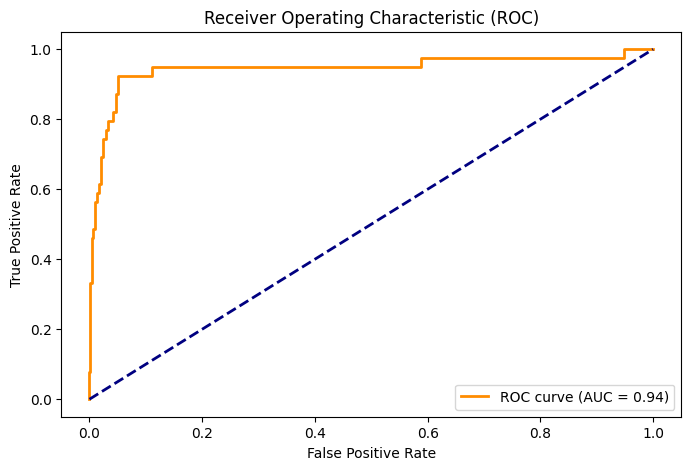

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

---

# Task 3.
Plot the Precision-Recall curve for your model using sklearn.metrics.precision_recall_curve and matplotlib, and explain in one line why this curve is useful for imbalanced datasets.<br><br><em><strong>Hint:</strong> Focus on how precision and recall behave when the positive class is rare.</em>

In [10]:
from sklearn.metrics import precision_recall_curve

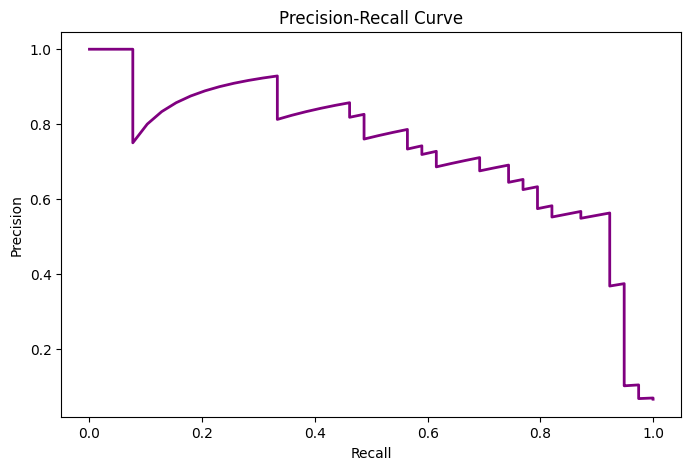

In [11]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

**Explanation:**
Because the positive class (fraud) is incredibly rare, the PR curve is much more informative than ROC; it completely ignores the massive number of "True Negatives" (normal transactions) and solely focuses on how well the model catches actual fraud without raising false alarms.

---

# Task 4.
Calculate the log loss (cross-entropy loss) for your test set predictions using sklearn.metrics.log_loss and print the result.

In [12]:
from sklearn.metrics import log_loss

In [13]:
loss = log_loss(y_test, y_probs)
print(f"Log Loss: {loss:.4f}")

Log Loss: 0.1112


---

# Task 5.
Change the class distribution in your test set to be even more imbalanced (e.g., only 2% positive class), re-calculate accuracy, AUC, and log loss, and write 2 lines explaining which metric is most misleading and why.<br><br><em><strong>Hint:</strong> Accuracy can be high even if the model ignores the minority class.</em>

In [14]:
X_severe, y_severe = make_classification(
    n_samples=1000, n_features=10, weights=[0.98, 0.02], random_state=99
)

severe_probs = log_model.predict_proba(X_severe)[:, 1]
severe_preds = log_model.predict(X_severe)

In [15]:
from sklearn.metrics import accuracy_score

In [16]:
severe_acc = accuracy_score(y_severe, severe_preds)
fpr_s, tpr_s, _ = roc_curve(y_severe, severe_probs)
severe_auc = auc(fpr_s, tpr_s)
severe_loss = log_loss(y_severe, severe_probs)

print(f"Severe Imbalance Accuracy: {severe_acc}")
print(f"Severe Imbalance AUC:      {severe_auc}")
print(f"Severe Imbalance Log Loss: {severe_loss}")

Severe Imbalance Accuracy: 0.88
Severe Imbalance AUC:      0.5246328551912569
Severe Imbalance Log Loss: 0.31772163039144136


**Explanation:**
**Accuracy** is the most misleading metric here by far! Because normal transactions make up 98% of the data, a completely "broken" model that just blindly predicts "Normal" for every single swipe will still magically score 98% accuracy, completely failing its actual job of catching fraud.